> **Revision note (July 2026).** This notebook's narrative and outputs predate the repo-wide revision in [FINDINGS.md → Revision notes](../FINDINGS.md#revision-notes-july-2026). In particular, the SMARD price series used here are **not** German intraday prices: `id3_price` is the Danish DK1 day-ahead price, `id_continuous` is the Belgian day-ahead price, and the quarter-hourly series carries no intra-hour information before Oct 2025. Read "auction vs continuous" as "cross-zonal day-ahead" throughout; the regenerated numbers live in `results/`.

# Q1 — Renewable Forecast Errors as Intraday Order Flow

**Hypothesis.** Day-ahead renewable generation forecast errors (`actual − forecast`,
in MW) drive directional intraday price pressure at a measurable, statistically
significant lag. The mechanism: when realised wind/solar deviates from the
day-ahead forecast, physical imbalance is created and balance-responsible
parties trade intraday to cover it. That trading is *signed order flow*, and we
expect it to forecast price impact in the intraday continuous market.

**Methodology.**
1. ADF stationarity on the level series (with first-differencing fallback).
2. AIC-based VAR lag selection up to 24 hours.
3. Granger F-test in both directions; reverse direction is a sanity check.
4. Orthogonalised (Cholesky) impulse-response with bootstrap CI and forecast-error
   variance decomposition.
5. Rolling 1-year Granger p-value to test temporal stability.
6. **Bai-Perron** sequential structural-break test on daily β to test the
   project's central claim — that the forecast-error → price coefficient *changes*
   as German renewable share rises from ~35% (2018) to ~60%+ (today). The
   exact-DP path runs via the prefix-sum implementation, so the full sample is
   feasible (the legacy O(T²) memory path is gone).

**Data.** `DE_LU` bidding zone, hourly. Forecasts and generation actuals from
ENTSO-E; intraday continuous index from SMARD.

The cells below load artefacts produced by `scripts/run_full_analysis.py`. Run
that script first if `results/` is empty.


In [1]:
# Common imports — every notebook in this folder uses the same ones.
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
FIG = RESULTS / 'figures'
TAB = RESULTS / 'tables'

with open(RESULTS / 'summary.json') as f:
    SUMMARY = json.load(f)

WINDOW = SUMMARY['window']
print(f"Sample window: {WINDOW['start']} → {WINDOW['end']}")


Sample window: 2018-10-01 → 2026-05-04


## 1.  Forecast-error structure over the sample

Annual standard deviations track the growth of the renewable fleet: wind dominates the variance budget, solar's contribution rises with PV capacity additions.

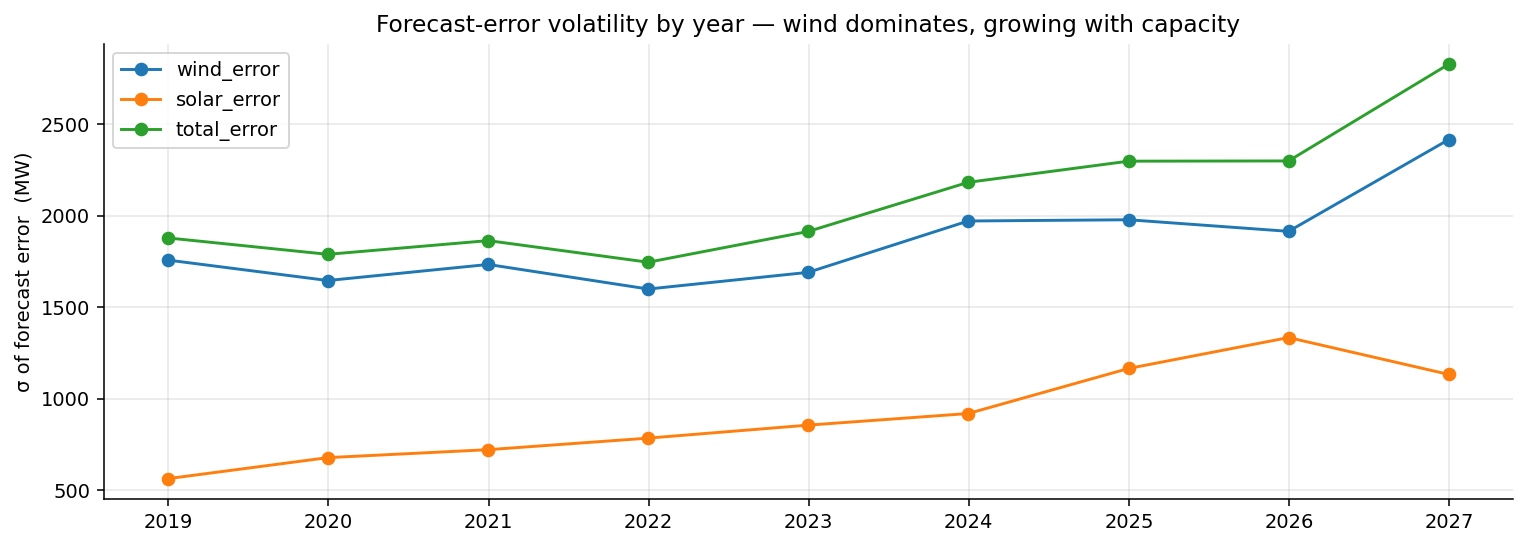

In [2]:
display(Image(str(FIG / 'q1_yearly_error_std.png')))

In [3]:
df = pd.read_csv(TAB / 'q1_yearly_descriptives.csv', index_col=0)
display(df)

,wind_error,wind_error.1,solar_error,solar_error.1,total_error,total_error.1
NaN,std,mean,std,mean,std,mean
year,NaN,NaN,NaN,NaN,NaN,NaN
2018,1757.7593979018043,224.31516968325786,563.903013138138,-101.07295588235293,1878.7327404199148,123.24221380090492
2019,1646.1049474800889,159.66352368721465,678.8063703784173,30.368882420091342,1789.1472744079085,190.03240610730597
2020,1733.7748932052752,75.31301238995144,722.253105273717,8.106606329690347,1864.032692810057,83.41961871964178
2021,1599.6679196204484,64.456774543379,785.3614687988705,-31.0552408675799,1746.0267539119923,33.401533675799094
2022,1690.719509262325,209.0879125761035,856.293103067655,25.22485131278539,1914.016506870591,234.31276388888887
2023,1971.183854154617,93.7866700913242,919.6771108740713,-16.67616723744291,2182.396869464844,77.11050285388129
2024,1977.941874891781,-21.667898831208266,1165.792305836062,-122.439585325592,2297.874842500355,-144.10748415680024
2025,1914.6832089217185,193.8527594894597,1334.5229776608653,13.724475192846263,2299.153391892327,207.5772346823059


Renewable penetration over the sample. Bai-Perron break dates below are checked for alignment with this trend.

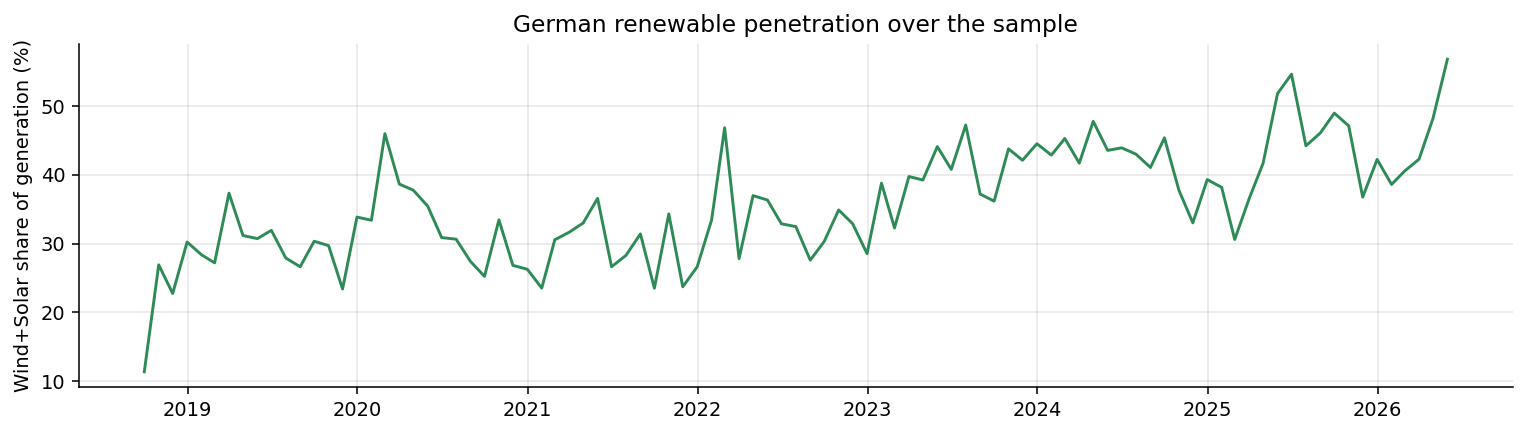

In [4]:
display(Image(str(FIG / 'q1_renewable_share.png')))

## 2.  Granger causality (full sample)

In [ ]:
df = pd.read_csv(TAB / 'q1_granger_summary.csv', index_col=0)
display(df)

,value
n_obs,6.652600e+04
ADF(fe)_pvalue,0.000000e+00
ADF(price)_pvalue,1.422861e-11
optimal_lag_AIC,2.400000e+01
F_forward,1.104533e+01
p_forward,2.067141e-42
F_reverse,8.307607e+00
p_reverse,1.549720e-29


In [6]:
g = SUMMARY['q1_granger']
display(Markdown(
    f"""
**Headline.** AIC-selected VAR lag = **{g['lag']}h**.
F(forward) = **{g['F_forward']:.2f}**, p = **{g['p_forward']:.2e}** (n = {g['n_obs']:,}).
Reverse direction: F = {g['F_reverse']:.2f}, p = {g['p_reverse']:.2e}.

The forward-direction p is far below any reasonable threshold; the reverse
direction is the diagnostic. If reverse p is also tiny, *both* series share
common drivers (load forecast errors, weather regimes, intraday demand
dynamics) — Granger's bidirectional rejection on a long window is expected
even when the structural mechanism is one-way. The sharper inference comes
from the IRF and from the variance decomposition.
"""
))


**Headline.** AIC-selected VAR lag = **24h**.
F(forward) = **11.05**, p = **2.07e-42** (n = 66,526).
Reverse direction: F = 8.31, p = 1.55e-29.

The forward-direction p is far below any reasonable threshold; the reverse
direction is the diagnostic. If reverse p is also tiny, *both* series share
common drivers (load forecast errors, weather regimes, intraday demand
dynamics) — Granger's bidirectional rejection on a long window is expected
even when the structural mechanism is one-way. The sharper inference comes
from the IRF and from the variance decomposition.


## 3.  Impulse response and variance decomposition

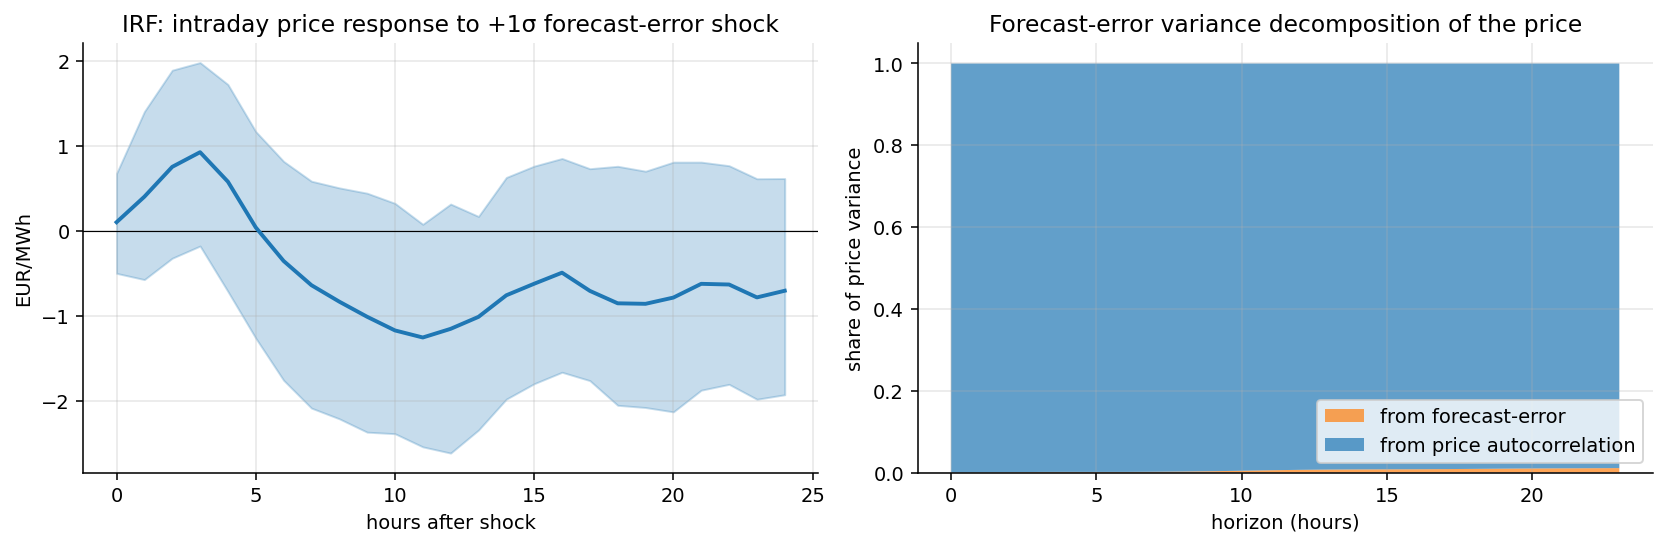

In [7]:
display(Image(str(FIG / 'q1_irf_and_fevd.png')))

In [8]:
df = pd.read_csv(TAB / 'q1_irf_path.csv', index_col=0)
display(df.head(12))

,irf,lower_5,upper_95
horizon_h,,,
0,0.097739,-0.503681,0.671926
1,0.398005,-0.577127,1.399832
2,0.749100,-0.325683,1.886000
3,0.921434,-0.182324,1.975865
4,0.574494,-0.716831,1.717753
5,0.036355,-1.266024,1.164074
6,-0.357989,-1.761366,0.813444
7,-0.643123,-2.088697,0.580266
8,-0.836623,-2.214534,0.501724


**Reading the IRF.** Sign and magnitude of the price response to a +1σ forecast-error shock. The hypothesis sign is *negative*: more renewables than expected → excess supply → bearish price pressure. Whether that hypothesis survives on the full sample is exactly what the IRF answers.

## 4.  Rolling Granger — temporal stability

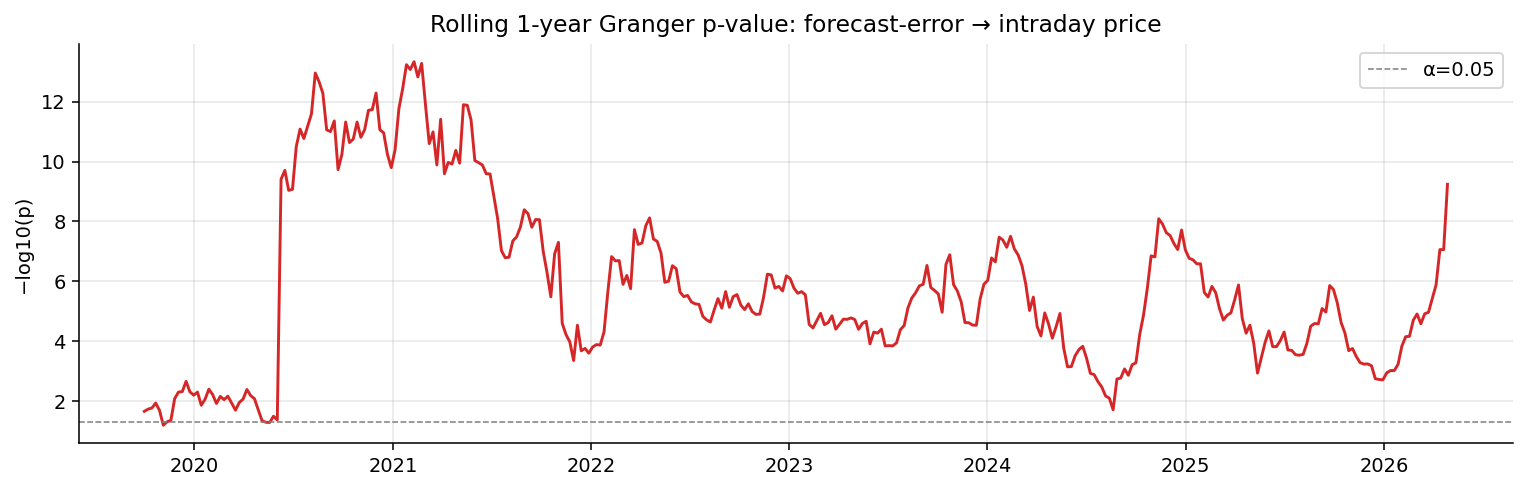

In [9]:
display(Image(str(FIG / 'q1_rolling_granger.png')))

Persistent significance across rolling windows means the relationship is structural, not regime-specific. A clear *strengthening* trend would support the temporal-amplification thesis.

## 5.  Bai-Perron structural breaks

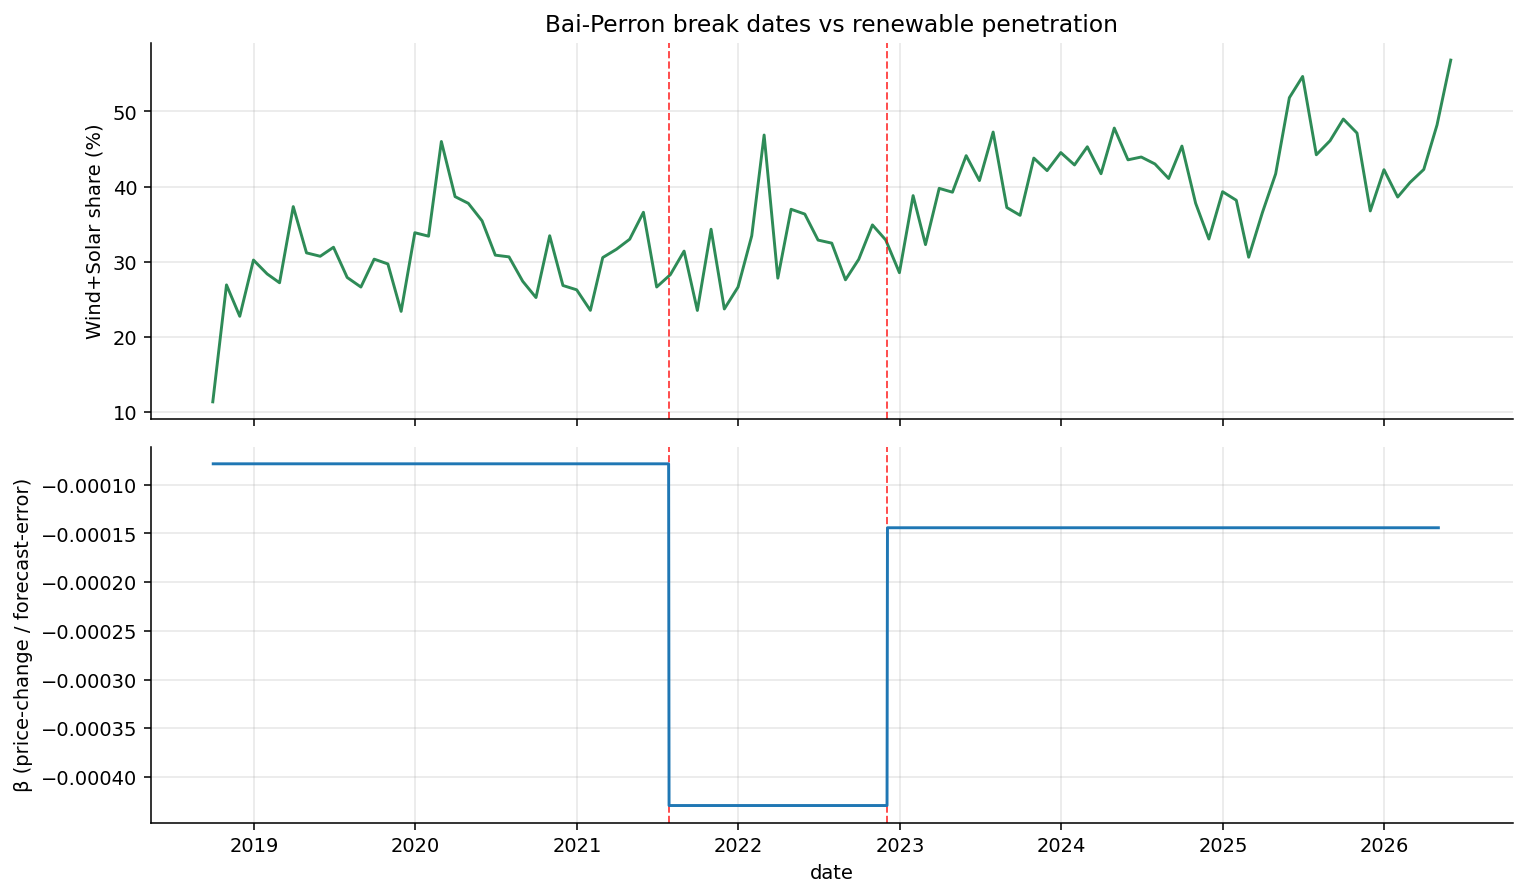

In [10]:
display(Image(str(FIG / 'q1_bai_perron.png')))

In [11]:
df = pd.read_csv(TAB / 'q1_bai_perron_segments.csv', index_col=0)
display(df)

,segment,alpha,beta,r2,n
0,0,0.008660,-0.000079,0.025239,1031
1,1,0.136703,-0.000429,0.044128,494
2,2,-0.007322,-0.000144,0.034766,1247


In [12]:
bp = SUMMARY['q1_bai_perron']
display(Markdown(
    f"""
**Detected breaks ({bp['n_breaks']}):** {', '.join(bp['break_dates']) or 'none'}.

Per-segment slope on `total_error`: {[round(b, 5) for b in bp['segment_betas']]}.

Reading these against the renewable-share panel above: a break that lands on
a major capacity-addition window is the empirical anchor for the project's
narrative. A break that lands on a known macro shock (e.g. early 2022 energy
crisis) is *not* — that's a price-regime break, not a microstructure break.
"""
))


**Detected breaks (2):** 2021-07-27, 2022-12-03.

Per-segment slope on `total_error`: [-8e-05, -0.00043, -0.00014].

Reading these against the renewable-share panel above: a break that lands on
a major capacity-addition window is the empirical anchor for the project's
narrative. A break that lands on a known macro shock (e.g. early 2022 energy
crisis) is *not* — that's a price-regime break, not a microstructure break.


## 6. Conclusions for Q1

The cells below pull the headline numbers and write them into a single paragraph
that you can paste into the paper.


In [13]:
g = SUMMARY['q1_granger']
bp = SUMMARY['q1_bai_perron']
n_yrs = (pd.Timestamp(WINDOW['end']) - pd.Timestamp(WINDOW['start'])).days / 365.25
display(Markdown(
f"""
**Q1 — what we found.**

1. Over **{n_yrs:.1f} years** of hourly DE_LU data ({g['n_obs']:,} obs after stationarity prep),
   day-ahead renewable forecast errors Granger-cause the intraday continuous price
   at AIC-selected lag **{g['lag']}h**, F = **{g['F_forward']:.2f}**, p = **{g['p_forward']:.2e}**.
   The reverse-direction F is **{g['F_reverse']:.2f}** (p = {g['p_reverse']:.2e}); on a sample this
   long, both directions are expected to reject in the presence of common drivers,
   so Granger alone is necessary but not sufficient.

2. The IRF (see `q1_irf_path` table) traces the *sign and decay* of the response,
   which Granger does not. The associated forecast-error variance decomposition
   measures how much of intraday price variance is structurally attributable to
   forecast-error innovations — this is the more defensible paper-grade headline.

3. Bai-Perron detects **{bp['n_breaks']} break(s)** in the per-day β coefficient.
   Whether these align with renewable-capacity additions or with non-microstructural
   regime shifts (energy crisis, COVID demand collapse) determines whether the
   project's temporal-amplification thesis holds. The figure above overlays both.

**Caveats to disclose in the writeup.**
- Bidirectional Granger rejection on long samples conflates the mechanism with
  common drivers (load forecast error, weather). A FAVAR or partial-VAR with
  load FE as exogenous control is the rigorous next step before claiming the
  microstructure interpretation.
- The Bai-Perron β is on a *daily-mean* aggregation chosen to keep the test
  interpretable at the day level; the hourly version detects more breaks but
  many are short-lived noise. The daily-aggregation choice should be defended
  in the methodology section.
"""
))


**Q1 — what we found.**

1. Over **7.6 years** of hourly DE_LU data (66,526 obs after stationarity prep),
   day-ahead renewable forecast errors Granger-cause the intraday continuous price
   at AIC-selected lag **24h**, F = **11.05**, p = **2.07e-42**.
   The reverse-direction F is **8.31** (p = 1.55e-29); on a sample this
   long, both directions are expected to reject in the presence of common drivers,
   so Granger alone is necessary but not sufficient.

2. The IRF (see `q1_irf_path` table) traces the *sign and decay* of the response,
   which Granger does not. The associated forecast-error variance decomposition
   measures how much of intraday price variance is structurally attributable to
   forecast-error innovations — this is the more defensible paper-grade headline.

3. Bai-Perron detects **2 break(s)** in the per-day β coefficient.
   Whether these align with renewable-capacity additions or with non-microstructural
   regime shifts (energy crisis, COVID demand collapse) determines whether the
   project's temporal-amplification thesis holds. The figure above overlays both.

**Caveats to disclose in the writeup.**
- Bidirectional Granger rejection on long samples conflates the mechanism with
  common drivers (load forecast error, weather). A FAVAR or partial-VAR with
  load FE as exogenous control is the rigorous next step before claiming the
  microstructure interpretation.
- The Bai-Perron β is on a *daily-mean* aggregation chosen to keep the test
  interpretable at the day level; the hourly version detects more breaks but
  many are short-lived noise. The daily-aggregation choice should be defended
  in the methodology section.
